**Exercícios Rotulação de Componentes Conexos**
exercícios obtidos em http://homepages.inf.ed.ac.uk/rbf/HIPR2/label.htm


1. Implemente o algoritmo de rotulação de componentes conexos (algoritmo do slide ou por outra solução) e aplique sobre a imagem binária art8.png. Indique qual vizinhança será considerada (4 ou 8)
Mostre os resultados na forma da imagem art8lab1.png e art8lab2.png

art8.png: 
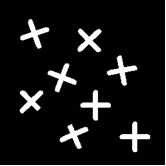
art8lab1.png: 
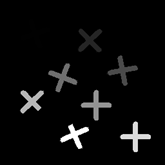
art8lab2.png: 
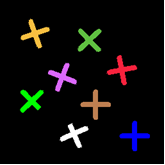
		

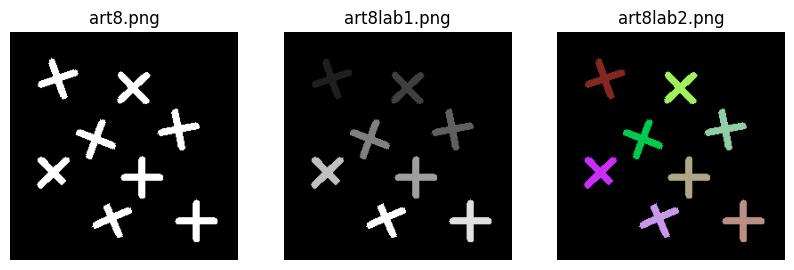

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagem = cv2.imread('art8.png', cv2.IMREAD_GRAYSCALE)

_, binaria = cv2.threshold(imagem, 127, 255, cv2.THRESH_BINARY)


num_labels, labels = cv2.connectedComponents(binaria, connectivity=8)

#print(labels)

#print("Quantidade de componentes:", num_labels - 1)


lab1 = np.zeros_like(imagem)

for i in range(1, num_labels):
    intensidade = int(i * 255 / num_labels)
    lab1[labels == i] = intensidade


lab2 = np.zeros((imagem.shape[0], imagem.shape[1], 3), dtype=np.uint8)

cores = np.random.randint(0, 255, size=(num_labels, 3))

for i in range(1, num_labels):
    lab2[labels == i] = cores[i]


plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(binaria, cmap='gray')
plt.title('art8.png')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(lab1, cmap='gray')
plt.title('art8lab1.png')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(lab2)
plt.title('art8lab2.png')
plt.axis('off')

plt.show()

2. Calcule o número de objetos da imagem clc3.png. Note que antes será necessário binarizar a imagem. Para isso, considere um limiar (*threshold*) de 67, isto é, valores acima de 167 na imagem original recebem zero, e os abaixo recebem 1 (o que resulta na imagem clc3thr1.png).

clc3.png
![clc3.png](clc3.png)
clc3thr1
![clc3thr1.png](clc3thr1.png)
clc3lab1
![clc3lab1.png](clc3lab1.png)
		

Quantidade de objetos: 217


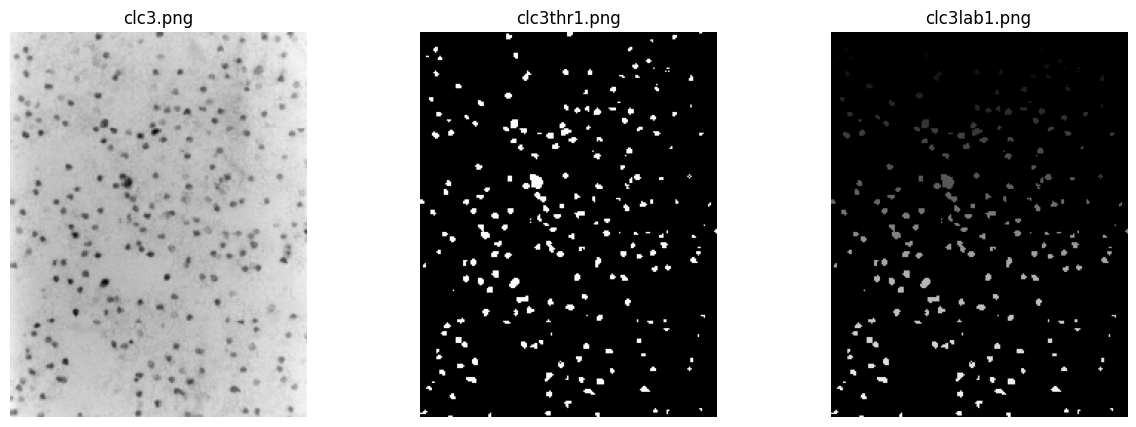

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagem = cv2.imread('clc3.png', cv2.IMREAD_GRAYSCALE)

if imagem is None:
    print("Erro ao carregar imagem")
    exit()



# abaixo de 167 -> branco
# acima de 167 -> preto

_, binaria = cv2.threshold(imagem, 167, 255, cv2.THRESH_BINARY_INV)



num_labels, labels = cv2.connectedComponents(binaria, connectivity=8)


quantidade_objetos = num_labels - 1

print("Quantidade de objetos:", quantidade_objetos)


lab = np.zeros_like(imagem)

for i in range(1, num_labels):
    intensidade = int(i * 255 / num_labels)
    lab[labels == i] = intensidade


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(imagem, cmap='gray')
plt.title('clc3.png')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(binaria, cmap='gray')
plt.title('clc3thr1.png')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(lab, cmap='gray')
plt.title('clc3lab1.png')
plt.axis('off')

plt.show()

3. Calcule a distância média entre os objetos da imagem anterior. Mostre um histograma com as distâncias e o valor médio.

Quantidade de objetos: 217
Distância média: 113.0548005522171


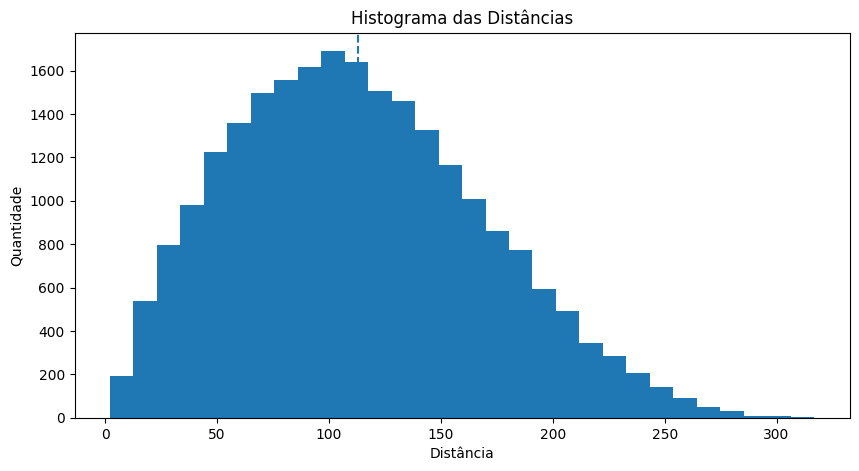

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


imagem = cv2.imread('clc3.png', cv2.IMREAD_GRAYSCALE)


_, binaria = cv2.threshold(imagem, 167, 255, cv2.THRESH_BINARY_INV)


num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
    binaria,
    connectivity=8
)

# remover fundo
centros = centroids[1:]


distancias = []

for i in range(len(centros)):
    for j in range(i + 1, len(centros)):

        x1, y1 = centros[i]
        x2, y2 = centros[j]

        distancia = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)

        distancias.append(distancia)

distancias = np.array(distancias)


media = np.mean(distancias)

print("Quantidade de objetos:", num_labels - 1)
print("Distância média:", media)


plt.figure(figsize=(10,5))

plt.hist(distancias, bins=30)

plt.title('Histograma das Distâncias')
plt.xlabel('Distância')
plt.ylabel('Quantidade')

plt.axvline(media, linestyle='dashed')

plt.show()

4. Mostra a Transformada Distância da imagem do exercício 1

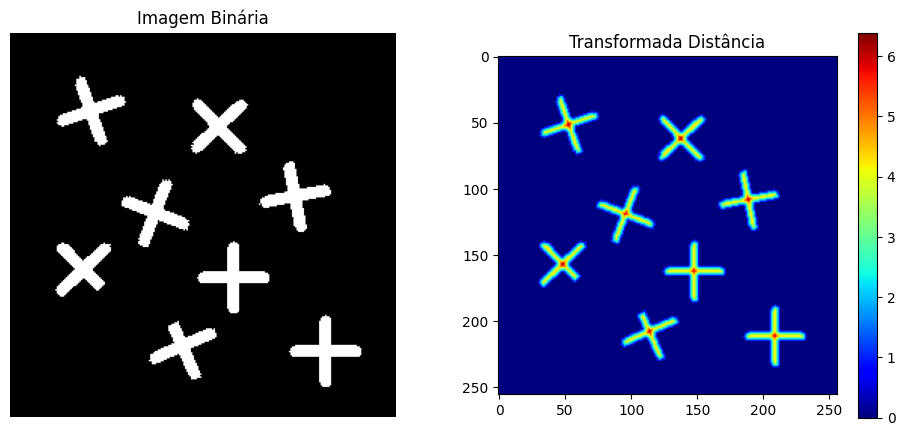

In [ ]:
import cv2
import matplotlib.pyplot as plt

imagem = cv2.imread('art8.png', cv2.IMREAD_GRAYSCALE)




_, binaria = cv2.threshold(imagem, 127, 255, cv2.THRESH_BINARY)


distancia = cv2.distanceTransform(
    binaria,
    cv2.DIST_L2,
    5
)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(binaria, cmap='gray')
plt.title('Imagem Binária')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(distancia, cmap='jet')
plt.title('Transformada Distância')
plt.colorbar()

plt.show()